# California House Prediction via Multi Regression

---

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

In [3]:
from sklearn.datasets import fetch_california_housing

california_ds = fetch_california_housing()
california_ds

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

---
#### Performing Some General Operation on Online Dataset


In [4]:
print(california_ds.keys())          # returns all attribute of dataset
# print(california_ds.DESCR)         # dataset description
print(california_ds.feature_names)   # all feature names

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


---
#### Converting Dataset into DataFrame

In [5]:
dataset = pd.DataFrame(california_ds.data, columns=california_ds.feature_names)

In [6]:
df = dataset

# Adding Target value to Dataset
df['Price'] = california_ds.target
df.head(3)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521


---
#### Slpit Dependent and Independent Features

In [7]:
X = df.drop('Price', axis=1)
y = df[['Price']]

---
#### Train Test Split

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.33, random_state=12)

---
#### Standariation

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)

---
#### Model Training

In [10]:
from sklearn.linear_model import LinearRegression

regressor = LinearRegression()
regressor.fit(X_train_scale, y_train)
y_pred = regressor.predict(X_test_scale)

---
#### Performance Metrices

In [11]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
adjusted_r2 = 1 - (1-r2)*(len(y_test)-1)/(len(y_test)-X_test_scale.shape[1]-1)

print("mae: ", mae)
print("mse: ",mse)
print("rmse",np.sqrt(mse))
print("r2: ", r2)
print("adj r2: ", adjusted_r2)

mae:  0.532823836236722
mse:  0.5309518068414643
rmse 0.7286643993234913
r2:  0.6047646030848887
adj r2:  0.6042998253140051


---
# Assumptions

In [12]:
# 8 slope for 8 features
print(regressor.coef_)

# one bias: at y, when all features are 0
print(regressor.intercept_)

# Accuracy of model is 
print(adjusted_r2*100)

[[ 0.8160491   0.11835219 -0.25538202  0.3034737  -0.00345005 -0.04064189
  -0.9039433  -0.87297273]]
[2.06527527]
60.429982531400505


---
#### Plot: Model Accuracy based on Dataset

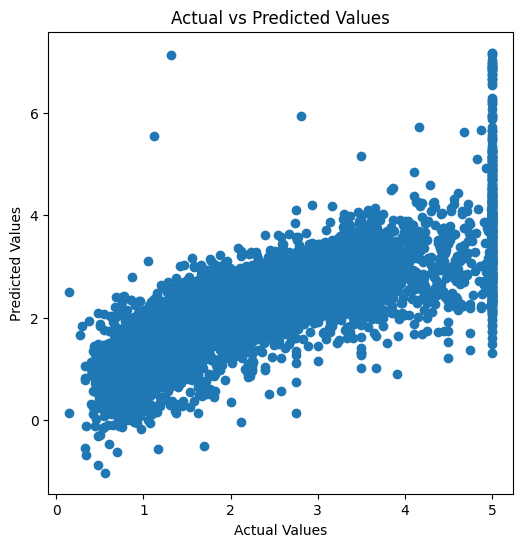

In [13]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()